In [71]:
import pandas as pd
import json
import os


In [72]:
def load_and_label_file(csv_path, json_path):
    df = pd.read_csv(csv_path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # is_incident = anomaly present
    df['is_incident'] = 0

    with open(ANOMALY_WINDOW_PATH, 'r') as f:
        labels_dict = json.load(f)

    file_name = os.path.basename(csv_path)

    anomaly_windows = []
    for key in labels_dict.keys():
        if file_name in key:
            anomaly_windows = labels_dict[key]
            break

    # apply labels
    for window in anomaly_windows:
        start_time = pd.to_datetime(window[0])
        end_time = pd.to_datetime(window[1])

        mask = (df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)
        df.loc[mask, 'is_incident'] = 1

    return df

df = load_and_label_file("data/ec2_cpu_utilization_fe7f93.csv", json_path)
print(df[df['is_incident'] == 1])

               timestamp  value  is_incident
698  2014-02-17 00:37:00  2.036            1
699  2014-02-17 00:42:00  1.864            1
700  2014-02-17 00:47:00  2.042            1
701  2014-02-17 00:52:00  1.846            1
702  2014-02-17 00:57:00  2.142            1
...                  ...    ...          ...
2665 2014-02-23 20:32:00  2.366            1
2666 2014-02-23 20:37:00  2.134            1
2667 2014-02-23 20:42:00  2.472            1
2668 2014-02-23 20:47:00  2.028            1
2669 2014-02-23 20:52:00  2.166            1

[405 rows x 3 columns]


In [73]:
import pywt
import numpy as np

def engineer_features(df, rolling_window_size=12):
    df = df.sort_values('timestamp').reset_index(drop=True)

    rolling_mean = df['value'].rolling(window=rolling_window_size, min_periods=1).mean()
    rolling_std = df['value'].rolling(window=rolling_window_size, min_periods=1).std()
    # prevent division by zero
    rolling_std = rolling_std.replace(0, 0.0001).fillna(0.0001)
    df['z_score'] = (df['value'] - rolling_mean) / rolling_std

    rolling_median = df['value'].rolling(window=rolling_window_size, min_periods=1).median()
    df['median_deviation'] = df['value'] - rolling_median

    chomp_threshold = rolling_median * 0.05
    df['clean_deviation'] = np.where(np.abs(df['median_deviation']) < chomp_threshold,0, df['median_deviation'])
    # timestamp -> continuous hour
    time_in_hours = df['timestamp'].dt.hour + df['timestamp'].dt.minute / 60.0

    def get_haar_detail(window_data):
        # We need at least 2 points for a wavelet transform
        if len(window_data) < 2:
            return 0.0
        # cA = smooth trend, cD = detail/jitter
        cA, cD = pywt.dwt(window_data, 'haar')
        return np.max(np.abs(cD))

    # Apply wavelet over a short, tight 4-step window (20 minutes)
    df['wavelet_jitter'] = df['value'].rolling(window=4, min_periods=2).apply(get_haar_detail, raw=True).fillna(0)
    # cyclical encoding
    df['hour_sin'] = np.sin(2 * np.pi * time_in_hours / 24.0)
    df['hour_cos'] = np.cos(2 * np.pi * time_in_hours / 24.0)

    return df
df = engineer_features(df, rolling_window_size=12)
print(df)

               timestamp  value  is_incident   z_score  median_deviation  \
0    2014-02-14 14:27:00  2.296            0  0.000000             0.000   
1    2014-02-14 14:32:00  2.144            0 -0.707107            -0.076   
2    2014-02-14 14:37:00  2.274            0  0.438243             0.000   
3    2014-02-14 14:42:00  2.066            0 -1.182806            -0.143   
4    2014-02-14 14:47:00  2.350            0  1.058400             0.076   
...                  ...    ...          ...       ...               ...   
4027 2014-02-28 14:02:00  2.456            0 -0.572293            -0.177   
4028 2014-02-28 14:07:00  2.098            0 -0.777141            -0.476   
4029 2014-02-28 14:12:00  2.376            0 -0.532788            -0.198   
4030 2014-02-28 14:17:00  2.426            0 -0.360656            -0.076   
4031 2014-02-28 14:22:00  3.252            0  2.127578             0.750   

      clean_deviation  wavelet_jitter  hour_sin  hour_cos  
0               0.000      

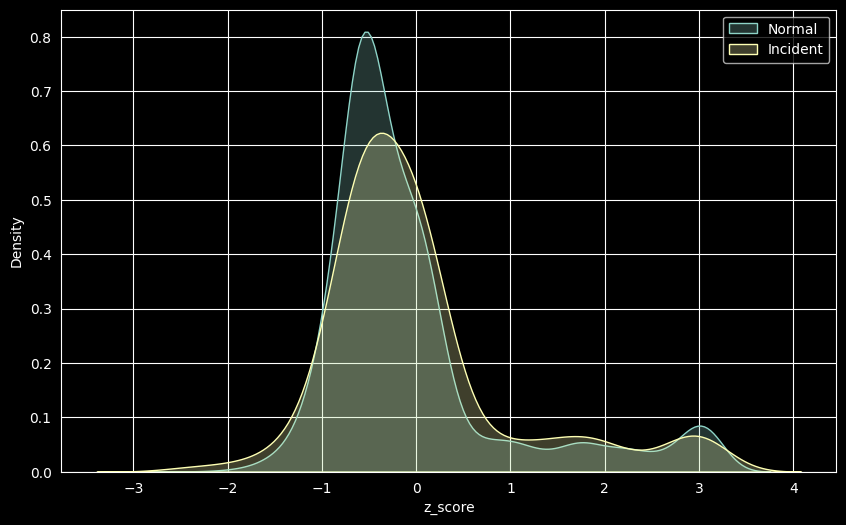

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df_features['is_incident'] == 0], x='z_score', label='Normal', fill=True)
sns.kdeplot(data=df[df_features['is_incident'] == 1], x='z_score', label='Incident', fill=True)

plt.legend()
plt.show()

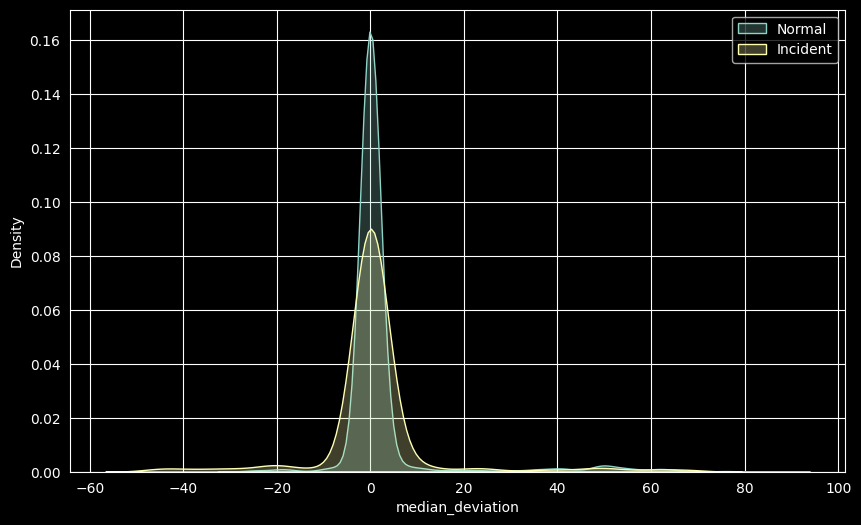

In [75]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=df[df_features['is_incident'] == 0], x='median_deviation', label='Normal', fill=True)
sns.kdeplot(data=df[df_features['is_incident'] == 1], x='median_deviation', label='Incident', fill=True)

plt.legend()
plt.show()

In [76]:
import numpy as np

def create_predictive_windows(df, feature_cols, W=12, H=3):

    # Create a copy so we don't modify the original dataframe
    df_window = df.copy()

    # 1. SHIFT THE TARGET (The Early Warning Magic)
    # If any of the next H steps is an incident, label current step as 1
    df_window['predictive_target'] = df_window['is_incident'].rolling(window=H, min_periods=1).max().shift(-H)

    # Drop the last H rows because we can't see into the future to label them
    df_window = df_window.dropna(subset=['predictive_target']).reset_index(drop=True)

    X = []
    y = []

    # 2. CREATE THE SLIDING BLOCKS
    # We start at index W, so we always have a full W steps of history to look back at
    for i in range(W, len(df_window)):
        # Extract the past W rows for our specific features
        # loc[i-W : i-1] grabs exactly W rows
        window_data = df_window.loc[i-W:i-1, feature_cols].values

        # Flatten the 2D window (W x Features) into a 1D array for Scikit-Learn
        X.append(window_data.flatten())

        # Grab the shifted target for this exact moment
        y.append(df_window.loc[i, 'predictive_target'])

    return np.array(X), np.array(y)

# Let's test it on your features!
# We will drop the raw 'value' and use our engineered features
features_to_use = ['z_score', 'clean_deviation', 'wavelet_jitter', 'hour_sin', 'hour_cos']

X_matrix, y_matrix = create_predictive_windows(df, features_to_use, W=12, H=3)

print(f"X  shape: {X_matrix.shape}")
print(f"y  shape: {y_matrix.shape}")

X  shape: (4017, 60)
y  shape: (4017,)


In [77]:
# 1. Create a temporary copy to test the shift
df_check = df_features.copy()
H = 3 # 15 minutes ahead

# 2. Apply the exact same shifting logic
df_check['predictive_target'] = df_check['is_incident'].rolling(window=H, min_periods=1).max().shift(-H)

# 3. Find the exact row index where the FIRST real incident starts
first_incident_idx = df_check[df_check['is_incident'] == 1].index[0]

# 4. Slice the dataframe to look at 5 rows BEFORE the incident, and 2 rows AFTER
start_idx = first_incident_idx - 5
end_idx = first_incident_idx + 2

# 5. Print out the specific columns to compare them
print("Checking the Early Warning Shift (H=3 steps / 15 mins):")
print(df_check.loc[start_idx:end_idx, ['timestamp', 'value', 'is_incident', 'predictive_target']])

Checking the Early Warning Shift (H=3 steps / 15 mins):
              timestamp  value  is_incident  predictive_target
693 2014-02-17 00:12:00  1.986            0                0.0
694 2014-02-17 00:17:00  3.532            0                0.0
695 2014-02-17 00:22:00  1.854            0                1.0
696 2014-02-17 00:27:00  2.144            0                1.0
697 2014-02-17 00:32:00  1.872            0                1.0
698 2014-02-17 00:37:00  2.036            1                1.0
699 2014-02-17 00:42:00  1.864            1                1.0
700 2014-02-17 00:47:00  2.042            1                1.0


In [78]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. Define the files we selected for the TRAINING set
train_files = [
    "data/ec2_cpu_utilization_fe7f93.csv", # 3 anomalies
    "data/ec2_cpu_utilization_5f5533.csv", # 2 anomalies
    "data/ec2_cpu_utilization_24ae8d.csv", # 2 anomalies
    "data/ec2_cpu_utilization_825cc2.csv", # 1 anomaly
    "data/ec2_cpu_utilization_77c1ca.csv"  # 1 anomaly
]

json_path = "labels/combined_windows.json"
features_to_use = ['z_score', 'clean_deviation', 'wavelet_jitter', 'hour_sin', 'hour_cos']
W = 6 # 60 minutes look-back
H = 2  # 15 minutes look-ahead

# Lists to hold the data from all files
X_train_list = []
y_train_list = []

print("Building Training Dataset...")
for file_path in train_files:
    # Run the pipeline functions we built!
    df = load_and_label_file(file_path, json_path)
    df_feat = engineer_features(df, rolling_window_size=12)
    X_file, y_file = create_predictive_windows(df_feat, features_to_use, W=W, H=H)

    # Store the results
    X_train_list.append(X_file)
    y_train_list.append(y_file)
    print(f"Processed {file_path}: Found {y_file.sum()} early-warning positive labels.")

# 2. Stack all the individual file matrices into one master matrix
# np.vstack stacks arrays vertically (rows on top of rows)
X_train = np.vstack(X_train_list)
y_train = np.concatenate(y_train_list)

print(f"\nFINAL TRAINING DATA SHAPE:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")

# 3. Train the Random Forest!
print("\nTraining Random Forest Model...")
# class_weight='balanced' is CRITICAL because 95% of our data is '0' (Normal)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)

rf_model.fit(X_train, y_train)

print("Model Training Complete! 🚀")

Building Training Dataset...
Processed data/ec2_cpu_utilization_fe7f93.csv: Found 408.0 early-warning positive labels.
Processed data/ec2_cpu_utilization_5f5533.csv: Found 404.0 early-warning positive labels.
Processed data/ec2_cpu_utilization_24ae8d.csv: Found 404.0 early-warning positive labels.
Processed data/ec2_cpu_utilization_825cc2.csv: Found 344.0 early-warning positive labels.
Processed data/ec2_cpu_utilization_77c1ca.csv: Found 404.0 early-warning positive labels.

FINAL TRAINING DATA SHAPE:
X_train: (20120, 30)
y_train: (20120,)

Training Random Forest Model...
Model Training Complete! 🚀


In [79]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Define the unseen TEST files
test_files = [
    "data/ec2_cpu_utilization_53ea38.csv",
    "data/ec2_cpu_utilization_ac20cd.csv",
    "data/ec2_cpu_utilization_c6585a.csv"
]

X_test_list = []
y_test_list = []

print("Building Testing Dataset...")
for file_path in test_files:
    # 2. Apply the EXACT same pipeline to the test data
    df_test = load_and_label_file(file_path, json_path)
    df_test_feat = engineer_features(df_test, rolling_window_size=W)
    X_test_file, y_test_file = create_predictive_windows(df_test_feat, features_to_use, W=W, H=H)

    X_test_list.append(X_test_file)
    y_test_list.append(y_test_file)

# Stack the test matrices
X_test = np.vstack(X_test_list)
y_test = np.concatenate(y_test_list)

print(f"X_test shape: {X_test.shape}")
print(f"Total actual anomalies in test set: {y_test.sum()}\n")

# 3. Make Predictions!
print("Running Predictions on Unseen Servers...")
y_pred = rf_model.predict(X_test)

# 4. Evaluate the Results
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

print("=== CONFUSION MATRIX ===")
conf_matrix = confusion_matrix(y_test, y_pred)
print(f"True Negatives (Quiet server, stayed quiet): {conf_matrix[0][0]}")
print(f"False Positives (Quiet server, FALSE ALARM): {conf_matrix[0][1]}")
print(f"False Negatives (Server crashed, MISSED IT): {conf_matrix[1][0]}")
print(f"True Positives (Server crashed, CAUGHT IT):  {conf_matrix[1][1]}")

Building Testing Dataset...
X_test shape: (12072, 30)
Total actual anomalies in test set: 808.0

Running Predictions on Unseen Servers...
=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       0.93      1.00      0.97     11264
         1.0       0.00      0.00      0.00       808

    accuracy                           0.93     12072
   macro avg       0.47      0.50      0.48     12072
weighted avg       0.87      0.93      0.90     12072

=== CONFUSION MATRIX ===
True Negatives (Quiet server, stayed quiet): 11263
False Positives (Quiet server, FALSE ALARM): 1
False Negatives (Server crashed, MISSED IT): 808
True Positives (Server crashed, CAUGHT IT):  0


<Figure size 800x600 with 0 Axes>

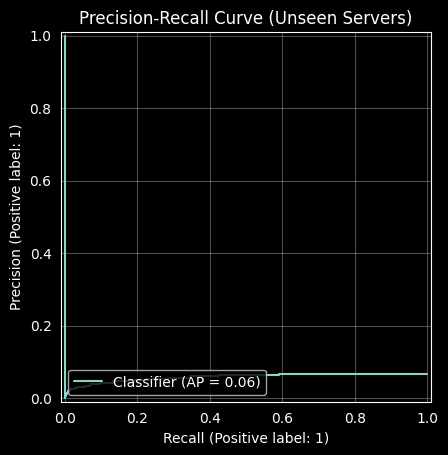

=== CONFUSION MATRIX (Threshold: 0.15) ===
True Negatives:  8874
False Positives: 2390  <-- Keep an eye on this!
False Negatives: 701
True Positives:  107  <-- Did we catch them?!

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

         0.0       0.93      0.79      0.85     11264
         1.0       0.04      0.13      0.06       808

    accuracy                           0.74     12072
   macro avg       0.48      0.46      0.46     12072
weighted avg       0.87      0.74      0.80     12072



In [80]:
from sklearn.metrics import PrecisionRecallDisplay
import matplotlib.pyplot as plt

# 1. Ask for PROBABILITIES, not hard predictions
# predict_proba returns two columns: [Prob of 0, Prob of 1]. We want column 1.
y_probs = rf_model.predict_proba(X_test)[:, 1]

# 2. Plot the Precision-Recall Curve (Crucial for your JetBrains report!)
plt.figure(figsize=(8, 6))
display = PrecisionRecallDisplay.from_predictions(y_test, y_probs)
display.ax_.set_title("Precision-Recall Curve (Unseen Servers)")
plt.grid(True, alpha=0.3)
plt.show()

# 3. Manually lower the decision threshold!
# Let's say: "If you are even 15% sure, sound the alarm!"
custom_threshold = 0.15
y_pred_custom = (y_probs >= custom_threshold).astype(int)

# 4. Evaluate the new threshold
print(f"=== CONFUSION MATRIX (Threshold: {custom_threshold}) ===")
conf_matrix_custom = confusion_matrix(y_test, y_pred_custom)
print(f"True Negatives:  {conf_matrix_custom[0][0]}")
print(f"False Positives: {conf_matrix_custom[0][1]}  <-- Keep an eye on this!")
print(f"False Negatives: {conf_matrix_custom[1][0]}")
print(f"True Positives:  {conf_matrix_custom[1][1]}  <-- Did we catch them?!")

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred_custom))

In [81]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Calculate precisions, recalls, and thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probs)

# 2. Find the index where Recall is closest to 80% (0.80)
# We want the highest threshold that still gives us >= 80% recall
target_recall = 0.80
idx = np.where(recalls >= target_recall)[0][-1]

optimal_threshold = thresholds[idx]
achieved_recall = recalls[idx]
achieved_precision = precisions[idx]

print(f"=== JETBRAINS TARGET ACHIEVED ===")
print(f"To get ~80% Recall, we need to set the threshold to: {optimal_threshold:.4f}")
print(f"At this threshold:")
print(f" - Recall:    {achieved_recall * 100:.2f}% (We catch the crashes!)")
print(f" - Precision: {achieved_precision * 100:.2f}% (But we get this many false alarms)")

# 3. Apply this exact threshold and see the Confusion Matrix
y_pred_80 = (y_probs >= optimal_threshold).astype(int)
conf_matrix_80 = confusion_matrix(y_test, y_pred_80)

print("\n=== FINAL CONFUSION MATRIX (80% Recall) ===")
print(f"True Negatives (Quiet server): {conf_matrix_80[0][0]}")
print(f"False Positives (FALSE ALARM): {conf_matrix_80[0][1]}")
print(f"False Negatives (MISSED IT):   {conf_matrix_80[1][0]}")
print(f"True Positives (CAUGHT IT):    {conf_matrix_80[1][1]}")

=== JETBRAINS TARGET ACHIEVED ===
To get ~80% Recall, we need to set the threshold to: 0.0500
At this threshold:
 - Recall:    81.56% (We catch the crashes!)
 - Precision: 6.54% (But we get this many false alarms)

=== FINAL CONFUSION MATRIX (80% Recall) ===
True Negatives (Quiet server): 1847
False Positives (FALSE ALARM): 9417
False Negatives (MISSED IT):   149
True Positives (CAUGHT IT):    659
